## Run ResNet-50 

**TASK:** Detect Insect Type \
**Dataset:** iNaturalist \
**Model:** Resnet-50 (pretrained)

In [14]:
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # silence tensorflow logging
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import models, transforms
from PIL import Image, ImageFile
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt

from utils.label_mappings import iNat_to_clean_map

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Data Loading

In [17]:
# custom mapping
class_dirs = ['Ant', 'Bee', 'Beetle', 'Butterfly', 'Grasshopper', 'Ladybug', 'Spider']
all_classes = class_dirs + ['Other']
num_classes = len(all_classes)
global_label_to_idx = {name: i for i, name in enumerate(all_classes)}

In [18]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [19]:
ds = load_dataset("sxj1215/inaturalist", split='train')

def get_iNat_label(messages): 
    return messages[1]['content']

In [20]:
# map labels
iNat36_label_df = pd.DataFrame({'messages': ds['messages']})
iNat36_label_df['species'] = iNat36_label_df['messages'].apply(lambda m: m[1]['content'])
iNat36_label_df['clean_label'] = iNat36_label_df['species'].map(
    lambda x: iNat_to_clean_map.get(x, 'Other') if iNat_to_clean_map.get(x) in class_dirs else 'Other'
)

In [21]:
# all valid insects for random/full experiments
all_indices = list(range(len(iNat36_label_df))) 
raw_curated = np.load('data/embs/finetuning_indexes_full_curated.npy').tolist()
cur_indices = [i for i in raw_curated if iNat36_label_df.iloc[i]['clean_label'] != 'Other']

In [22]:
# dataset classes

class InatPixelDataset(Dataset):
    def __init__(self, hf_dataset, indices, label_df, transform=None):
        self.hf_dataset, self.indices, self.label_df, self.transform = hf_dataset, indices, label_df, transform
    
    def __len__(self): 
        return len(self.indices)
    
    def __getitem__(self, idx):
        orig_idx = self.indices[idx]
        image = self.hf_dataset[orig_idx]['images'][0]
        label_str = self.label_df.iloc[orig_idx]['clean_label']
        if self.transform: 
            image = self.transform(image)
        return image, torch.tensor(global_label_to_idx[label_str], dtype=torch.long)

In [23]:
class KaggleTestDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths, self.transform = file_paths, transform
    
    def __len__(self): 
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label_name = os.path.basename(os.path.dirname(path))
        image = Image.open(path).convert('RGB')
        if self.transform: 
            image = self.transform(image)
        return image, torch.tensor(global_label_to_idx[label_name], dtype=torch.long)

In [24]:
# test set loading

test_base_path = 'data/clean_insect_images/'
test_files = []

for c in class_dirs:
    p = os.path.join(test_base_path, c)
    if os.path.exists(p):
        test_files.extend([os.path.join(p, f) for f in os.listdir(p) if f.lower().endswith(('.jpg', '.png'))])

test_loader = DataLoader(KaggleTestDataset(test_files, transform=preprocess), batch_size=32, shuffle=False)

### Model Functions

In [25]:
def get_partial_unfreeze_model():
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    for param in model.parameters(): 
        param.requires_grad = False
    
    for param in model.layer4.parameters(): 
        param.requires_grad = True
    
    for param in model.fc.parameters(): 
        param.requires_grad = True
        
    return model

In [31]:
def get_lora_model():
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    config = LoraConfig(r=32, lora_alpha=64, target_modules=["fc", "conv1", "downsample.0"], lora_dropout=0.1, bias="none")
    
    return get_peft_model(model, config)

In [27]:
def run_experiment(name, model_fn, dataset, test_loader):
    print(f"\n--- Starting Experiment: {name} ---")
    
    # setup data
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_set, _ = torch.utils.data.random_split(dataset, [train_size, val_size])
    t_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    
    model = model_fn().to(device)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # training
    start_train_time = time.time()
    for epoch in range(3):
        model.train()
        for imgs, labels in t_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    train_time = time.time() - start_train_time

    # evaluation
    model.eval()
    test_preds, test_probs, test_targets = [], [], []
    
    start_test_time = time.time()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            out = model(imgs)
            probs = torch.softmax(out, dim=1)
            
            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            test_targets.extend(labels.numpy())
    test_time = time.time() - start_test_time
    
    # metric calculations
    probs_array = np.array(test_probs)[:, :7] 
    probs_array = probs_array / probs_array.sum(axis=1, keepdims=True)
    
    acc = accuracy_score(test_targets, test_preds)
    f1 = f1_score(test_targets, test_preds, average='weighted')
    auc = roc_auc_score(test_targets, probs_array, multi_class='ovr', average='weighted')
    cm = confusion_matrix(test_targets, test_preds)

    # output/print
    print(f"Results for {name}:")
    print(f"  Test Accuracy:  {acc:.4f}")
    print(f"  Test Weight F1: {f1:.4f}")
    print(f"  Test AUC:       {auc:.4f}")
    print(f"  Train Time: {train_time:.2f}s | Test Time: {test_time:.4f}s")
    print("  Confusion Matrix:")

    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_dirs, yticklabels=class_dirs)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    res = {
        'name': name,
        'acc': acc,
        'f1': f1,
        'auc': auc,
        'train_time': train_time,
        'test_time': test_time,
        'conf_matrix': cm
    }
    return res

### Experiments

In [28]:
results_summary = {}

#### Curated

In [29]:
raw_curated = np.load('data/embs/finetuning_indexes_full_curated.npy').tolist()
curated_indices_filtered = [i for i in raw_curated if iNat36_label_df.iloc[i]['clean_label'] != 'Other']
cur_ds = InatPixelDataset(ds, curated_indices_filtered, iNat36_label_df, transform=preprocess)
cur_ds = InatPixelDataset(ds, cur_indices, iNat36_label_df, transform=preprocess)


--- Starting Experiment: Curated (Kairos) ---
Results for Curated (Kairos):
  Test Accuracy:  0.7427
  Test Weight F1: 0.7282
  Test AUC:       0.9514
  Train Time: 116.87s | Test Time: 179.1031s
  Confusion Matrix:


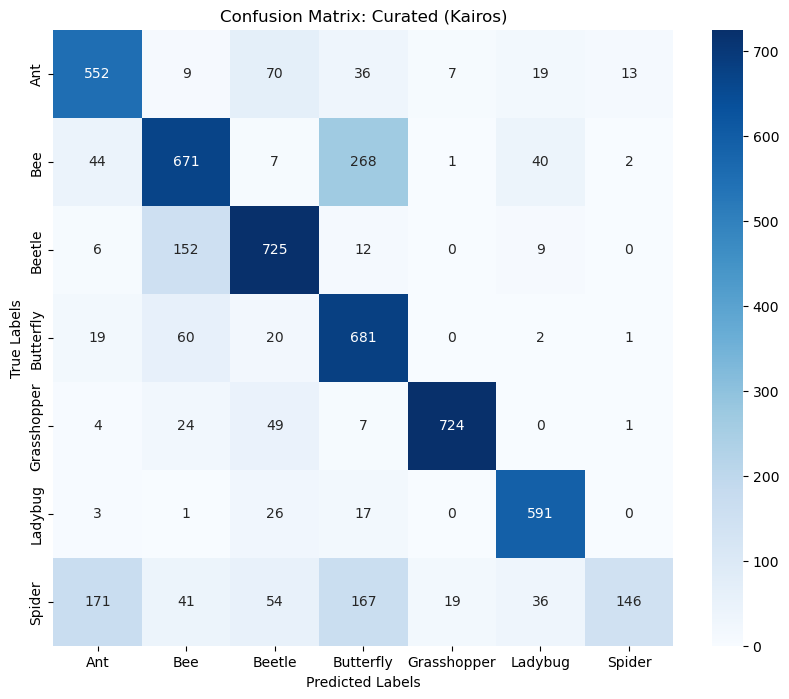

In [30]:
results_summary['Curated_partial'] = run_experiment("Curated (Partial Unfreezing)", get_partial_unfreeze_model, cur_ds, test_loader)


--- Starting Experiment: Curated (LoRA) ---
Results for Curated (LoRA):
  Test Accuracy:  0.4685
  Test Weight F1: 0.4009
  Test AUC:       0.9130
  Train Time: 115.34s | Test Time: 182.8513s
  Confusion Matrix:


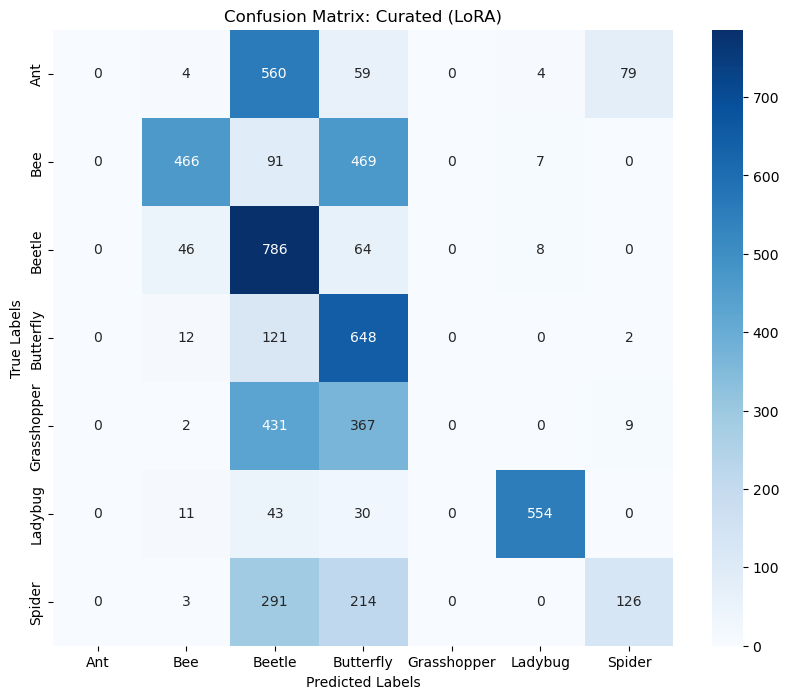

In [32]:
results_summary['Curated_LoRA'] = run_experiment("Curated (LoRA)", get_lora_model, cur_ds, test_loader)

#### Full iNat


--- Starting Experiment: Full iNat (Partial Unfreezing) ---
Results for Full iNat (Partial Unfreezing):
  Test Accuracy:  0.6219
  Test Weight F1: 0.6998
  Test AUC:       0.9599
  Train Time: 1681.02s | Test Time: 180.4809s
  Confusion Matrix:


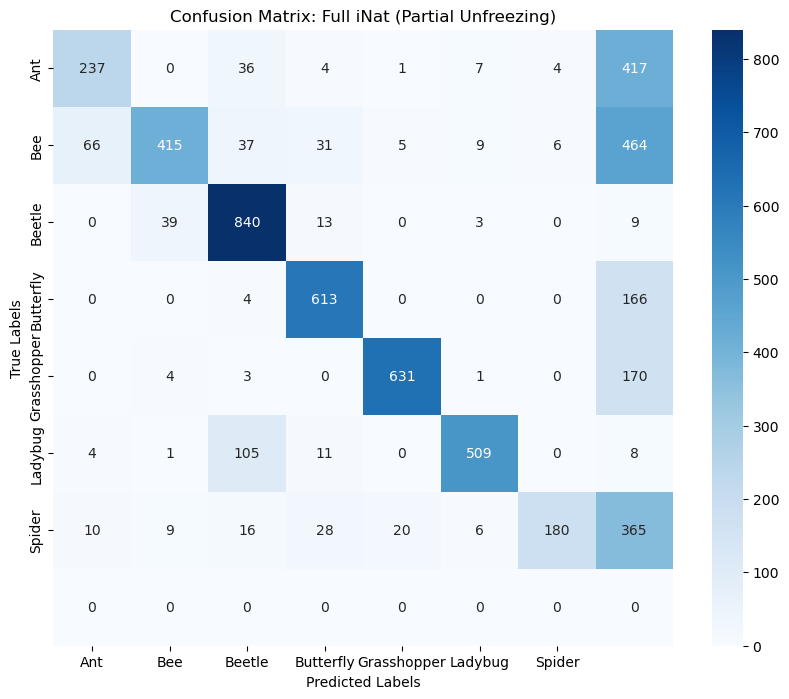

In [37]:
full_ds = InatPixelDataset(ds, all_indices, iNat36_label_df, transform=preprocess)
results_summary['Full_partial'] = run_experiment("Full iNat (Partial Unfreezing)", get_partial_unfreeze_model, full_ds, test_loader)


--- Starting Experiment: Full iNat (LoRA) ---
Results for Full iNat (LoRA):
  Test Accuracy:  0.4325
  Test Weight F1: 0.4617
  Test AUC:       0.9087
  Train Time: 1805.59s | Test Time: 182.6791s
  Confusion Matrix:


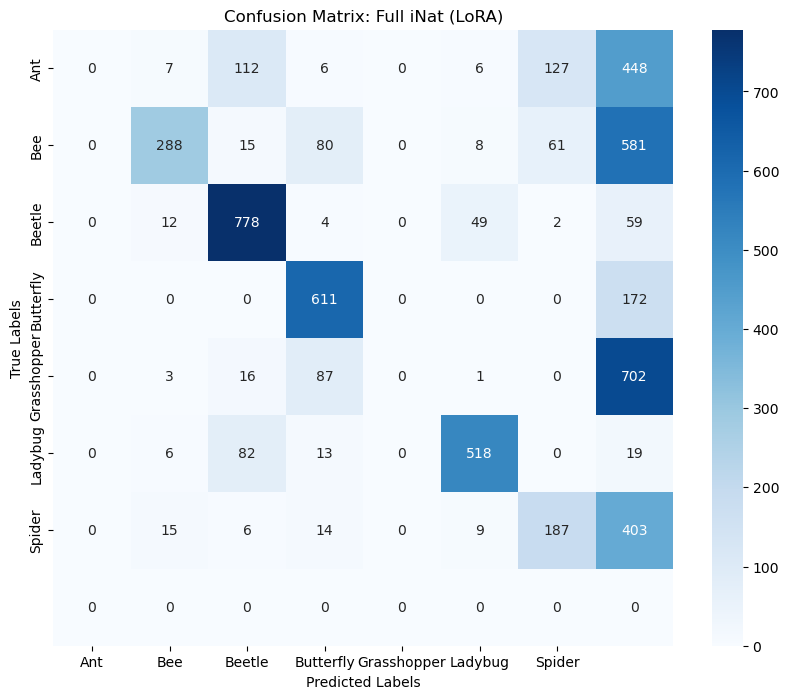

In [38]:
results_summary['Full_LoRA'] = run_experiment("Full iNat (LoRA)", get_lora_model, full_ds, test_loader)

#### Random Sample


--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.5618
  Test Weight F1: 0.6408
  Test AUC:       0.9600
  Train Time: 109.22s | Test Time: 174.2840s
  Confusion Matrix:


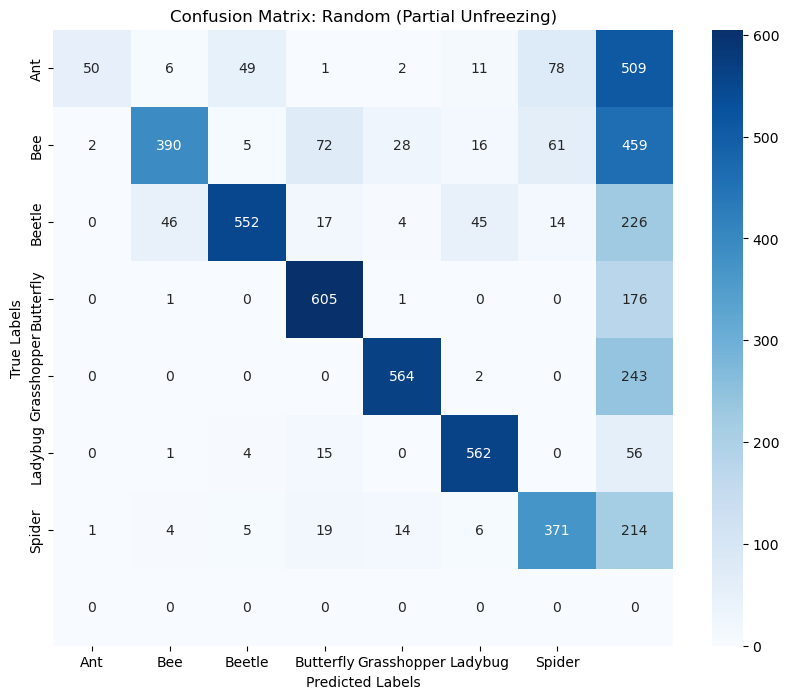

RESULT [Trial 1/10]: Acc: 0.5618 | F1: 0.6408 | AUC: 0.9600

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.4474
  Test Weight F1: 0.5113
  Test AUC:       0.9338
  Train Time: 105.48s | Test Time: 180.9864s
  Confusion Matrix:


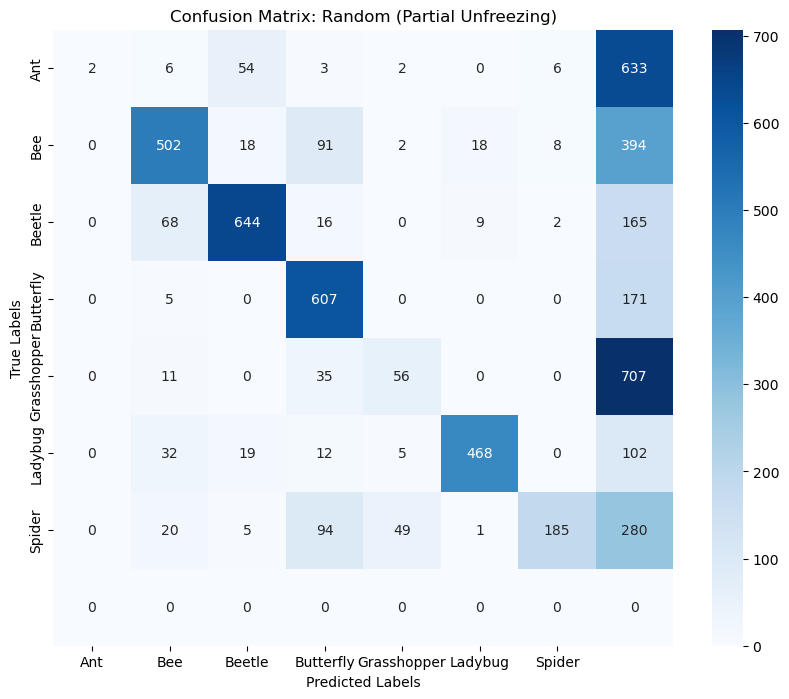

RESULT [Trial 2/10]: Acc: 0.4474 | F1: 0.5113 | AUC: 0.9338

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.5170
  Test Weight F1: 0.5457
  Test AUC:       0.9535
  Train Time: 112.76s | Test Time: 182.9593s
  Confusion Matrix:


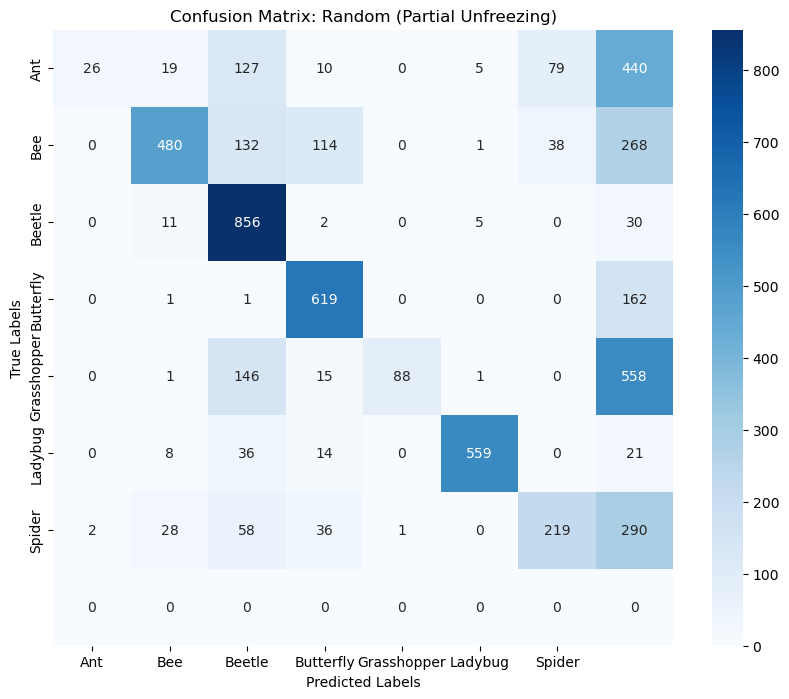

RESULT [Trial 3/10]: Acc: 0.5170 | F1: 0.5457 | AUC: 0.9535

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.5242
  Test Weight F1: 0.5987
  Test AUC:       0.9479
  Train Time: 110.08s | Test Time: 186.1831s
  Confusion Matrix:


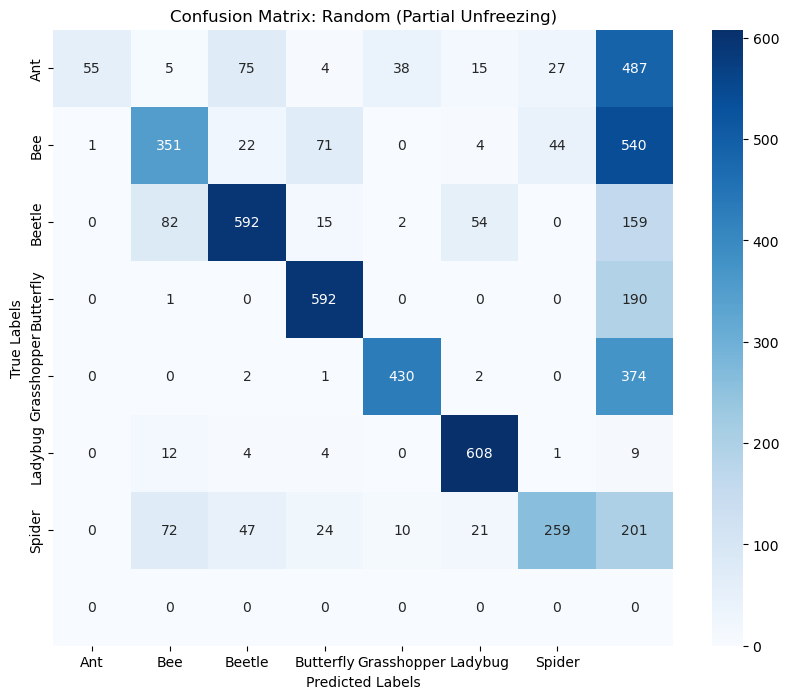

RESULT [Trial 4/10]: Acc: 0.5242 | F1: 0.5987 | AUC: 0.9479

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.4549
  Test Weight F1: 0.5218
  Test AUC:       0.9399
  Train Time: 113.33s | Test Time: 213.0076s
  Confusion Matrix:


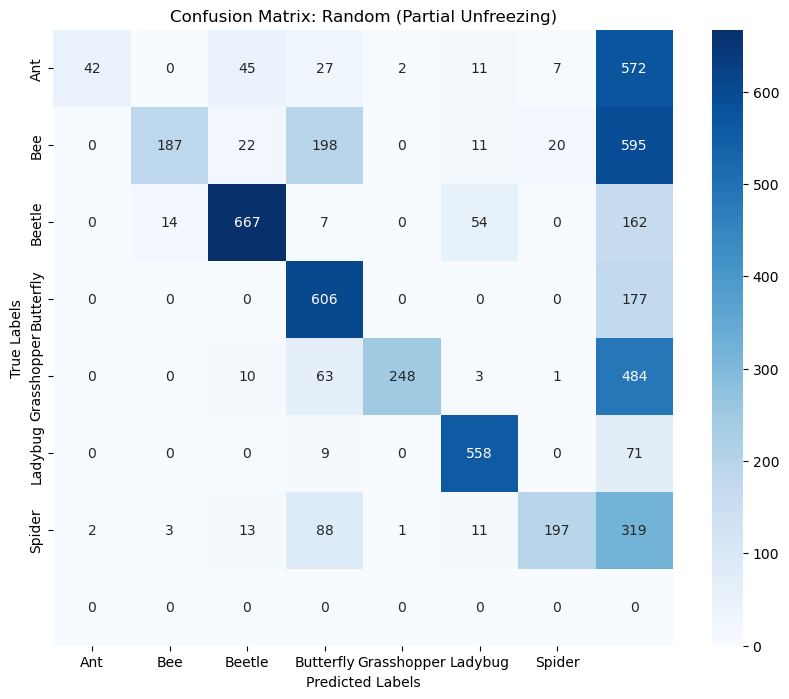

RESULT [Trial 5/10]: Acc: 0.4549 | F1: 0.5218 | AUC: 0.9399

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.3917
  Test Weight F1: 0.4634
  Test AUC:       0.9228
  Train Time: 148.45s | Test Time: 237.9799s
  Confusion Matrix:


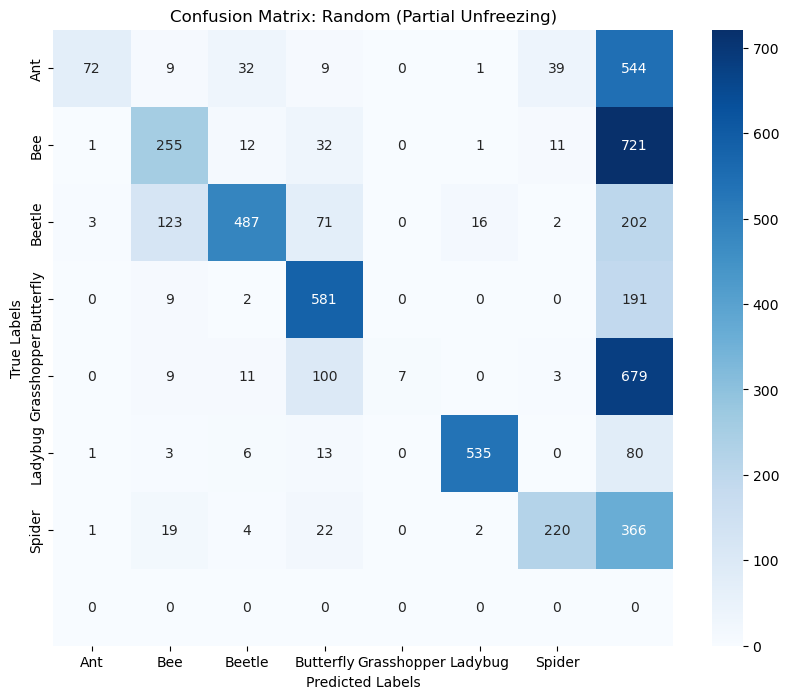

RESULT [Trial 6/10]: Acc: 0.3917 | F1: 0.4634 | AUC: 0.9228

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.3657
  Test Weight F1: 0.4194
  Test AUC:       0.9113
  Train Time: 149.87s | Test Time: 238.7313s
  Confusion Matrix:


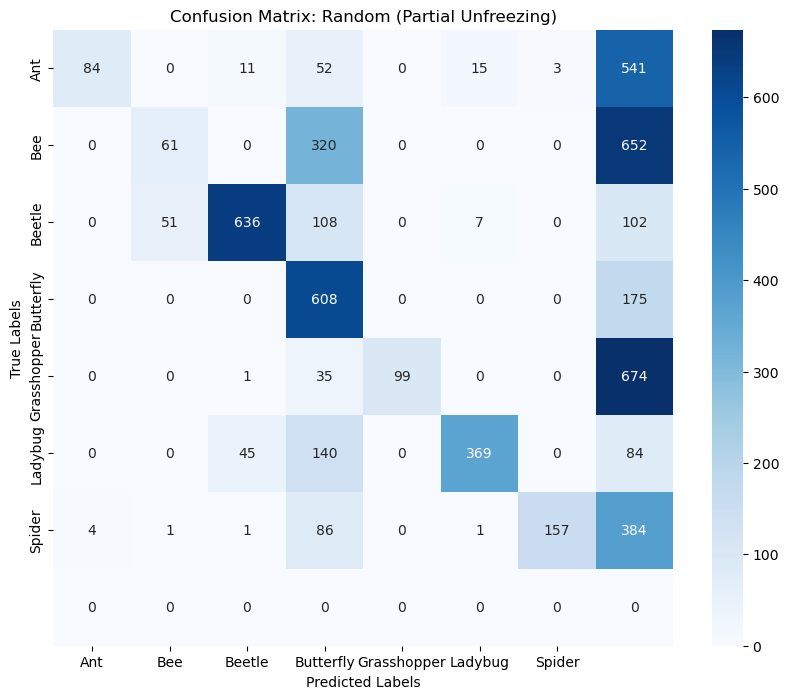

RESULT [Trial 7/10]: Acc: 0.3657 | F1: 0.4194 | AUC: 0.9113

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.4718
  Test Weight F1: 0.5192
  Test AUC:       0.9472
  Train Time: 149.86s | Test Time: 238.0868s
  Confusion Matrix:


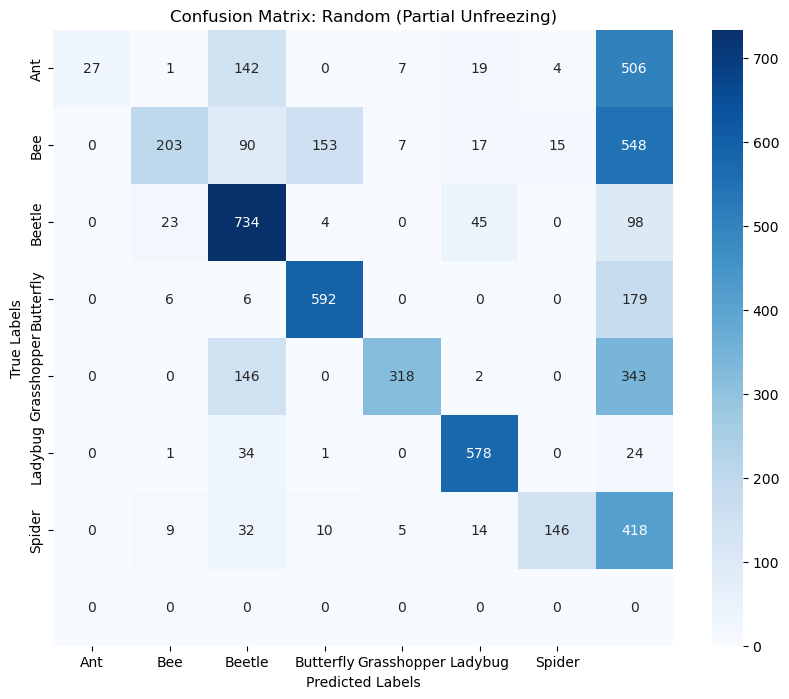

RESULT [Trial 8/10]: Acc: 0.4718 | F1: 0.5192 | AUC: 0.9472

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.5141
  Test Weight F1: 0.5723
  Test AUC:       0.9466
  Train Time: 150.41s | Test Time: 239.0683s
  Confusion Matrix:


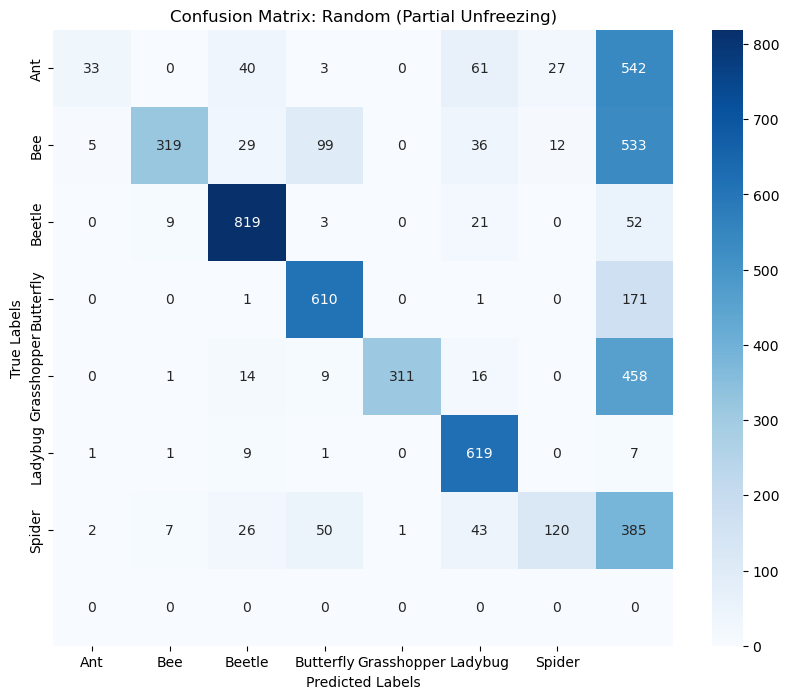

RESULT [Trial 9/10]: Acc: 0.5141 | F1: 0.5723 | AUC: 0.9466

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.4576
  Test Weight F1: 0.5051
  Test AUC:       0.9471
  Train Time: 151.84s | Test Time: 247.7679s
  Confusion Matrix:


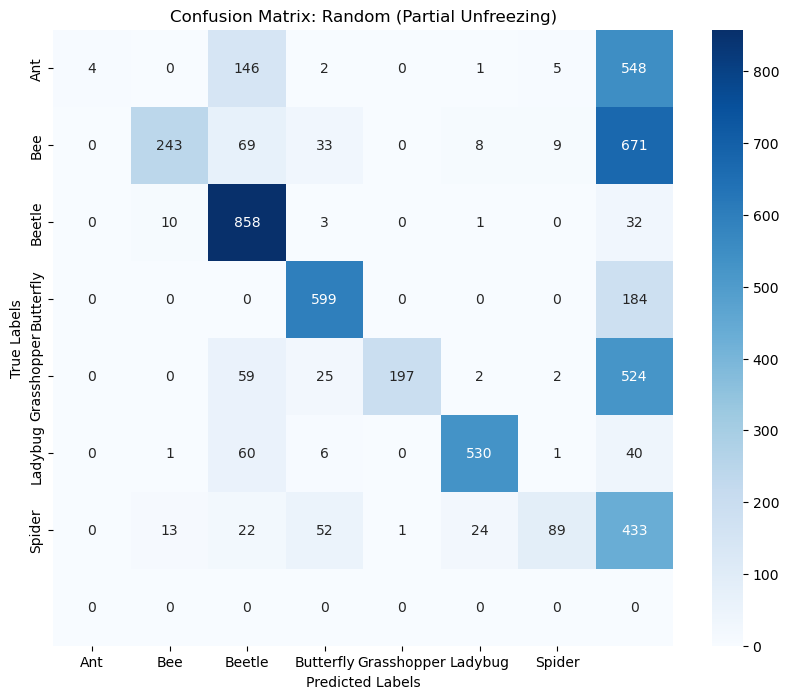

RESULT [Trial 10/10]: Acc: 0.4576 | F1: 0.5051 | AUC: 0.9471


In [41]:
target_size = len(cur_indices)
rand_metrics = []

for i in range(10):
    np.random.seed(42 + i)
    r_idx = np.random.choice(all_indices, size=target_size, replace=False).tolist()
    r_ds = InatPixelDataset(ds, r_idx, iNat36_label_df, transform=preprocess)
    
    # Run the trial
    res = run_experiment("Random (Partial Unfreezing)", get_partial_unfreeze_model, r_ds, test_loader)
    
    # show metrics each round
    print(f"RESULT [Trial {i+1}/10]: Acc: {res['acc']:.4f} | F1: {res['f1']:.4f} | AUC: {res['auc']:.4f}")
    rand_metrics.append(res)


In [43]:
results_summary

{'Curated_partial': {'name': 'Curated (Kairos)',
  'acc': 0.7426911203922281,
  'f1': 0.7281541795080376,
  'auc': 0.9514199615654844,
  'train_time': 116.87282633781433,
  'test_time': 179.10312581062317,
  'conf_matrix': array([[552,   9,  70,  36,   7,  19,  13],
         [ 44, 671,   7, 268,   1,  40,   2],
         [  6, 152, 725,  12,   0,   9,   0],
         [ 19,  60,  20, 681,   0,   2,   1],
         [  4,  24,  49,   7, 724,   0,   1],
         [  3,   1,  26,  17,   0, 591,   0],
         [171,  41,  54, 167,  19,  36, 146]])},
 'Curated_LoRA': {'name': 'Curated (LoRA)',
  'acc': 0.4684946431814055,
  'f1': 0.40091306844185093,
  'auc': 0.9129642409544372,
  'train_time': 115.34089088439941,
  'test_time': 182.85131645202637,
  'conf_matrix': array([[  0,   4, 560,  59,   0,   4,  79],
         [  0, 466,  91, 469,   0,   7,   0],
         [  0,  46, 786,  64,   0,   8,   0],
         [  0,  12, 121, 648,   0,   0,   2],
         [  0,   2, 431, 367,   0,   0,   9],
       

In [45]:
rand_metrics[0]

{'name': 'Random (Partial Unfreezing)',
 'acc': 0.5618303976756855,
 'f1': 0.6408064744831264,
 'auc': 0.9600073332490072,
 'train_time': 109.2199022769928,
 'test_time': 174.2840211391449,
 'conf_matrix': array([[ 50,   6,  49,   1,   2,  11,  78, 509],
        [  2, 390,   5,  72,  28,  16,  61, 459],
        [  0,  46, 552,  17,   4,  45,  14, 226],
        [  0,   1,   0, 605,   1,   0,   0, 176],
        [  0,   0,   0,   0, 564,   2,   0, 243],
        [  0,   1,   4,  15,   0, 562,   0,  56],
        [  1,   4,   5,  19,  14,   6, 371, 214],
        [  0,   0,   0,   0,   0,   0,   0,   0]])}

In [49]:
results_summary['Random (10-avg)'] = {
    'acc': np.mean([m['acc'] for m in rand_metrics]),
    'f1': np.mean([m['f1'] for m in rand_metrics]),
    'auc': np.mean([m['auc'] for m in rand_metrics]),
    'train_time': np.mean([m['train_time'] for m in rand_metrics]),
    'test_time': np.mean([m['test_time'] for m in rand_metrics]),
    'conf_matrix': rand_metrics[-1]['conf_matrix']
}


--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.1364
  Test Weight F1: 0.1453
  Test AUC:       0.6940
  Train Time: 168.77s | Test Time: 235.5462s
  Confusion Matrix:


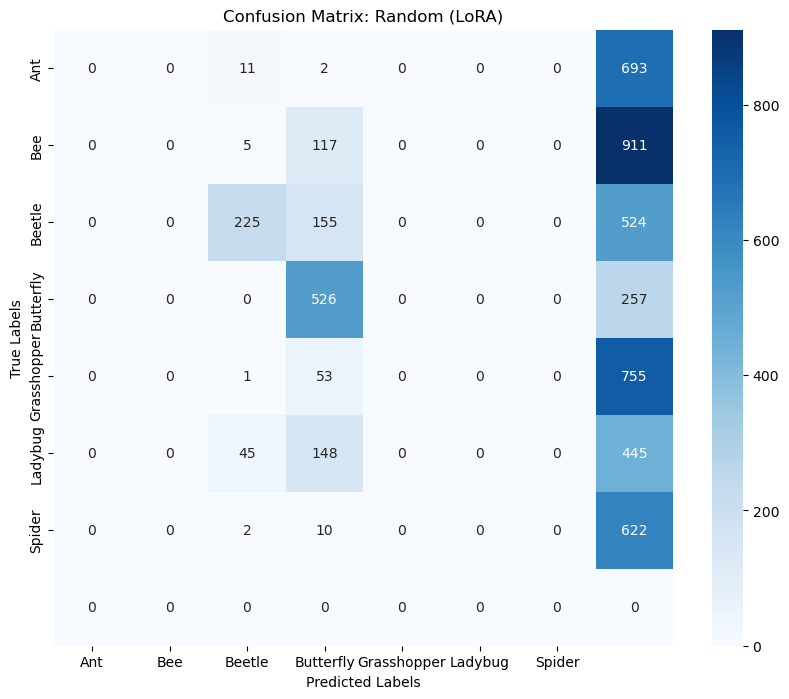

RESULT [Trial 1/10]: Acc: 0.1364 | F1: 0.1453 | AUC: 0.6940

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0098
  Test Weight F1: 0.0184
  Test AUC:       0.6161
  Train Time: 168.96s | Test Time: 251.0716s
  Confusion Matrix:


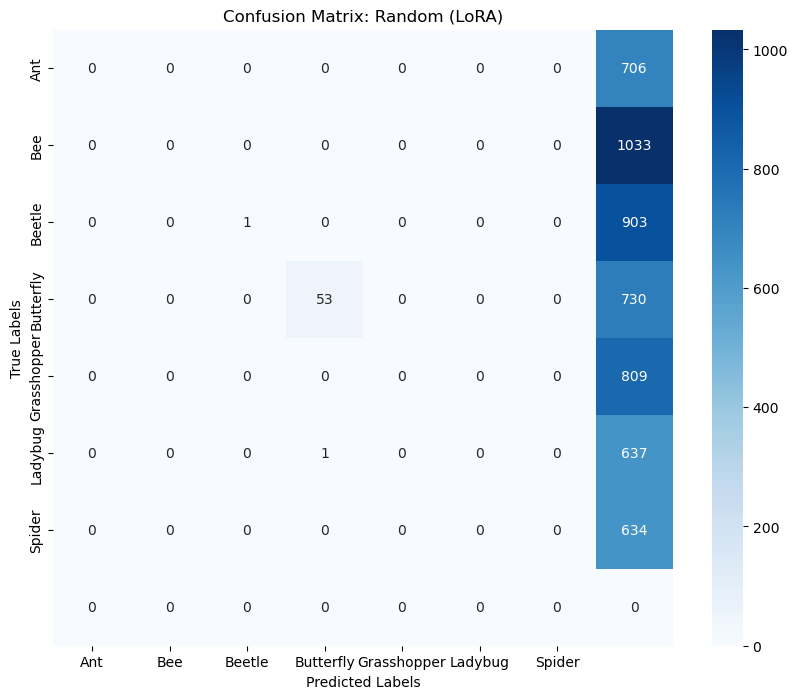

RESULT [Trial 2/10]: Acc: 0.0098 | F1: 0.0184 | AUC: 0.6161

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0225
  Test Weight F1: 0.0374
  Test AUC:       0.6020
  Train Time: 167.87s | Test Time: 263.0977s
  Confusion Matrix:


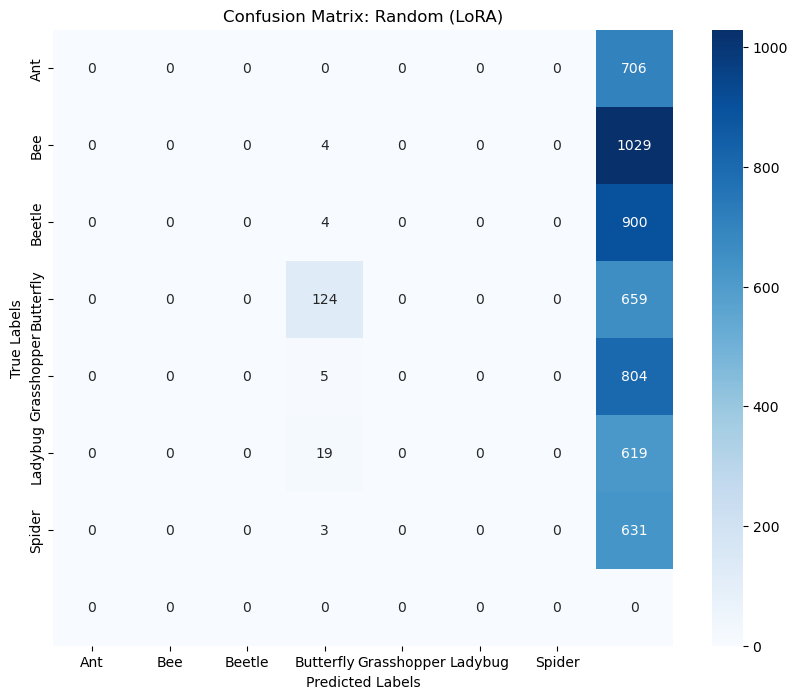

RESULT [Trial 3/10]: Acc: 0.0225 | F1: 0.0374 | AUC: 0.6020

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0189
  Test Weight F1: 0.0332
  Test AUC:       0.6335
  Train Time: 172.57s | Test Time: 260.9612s
  Confusion Matrix:


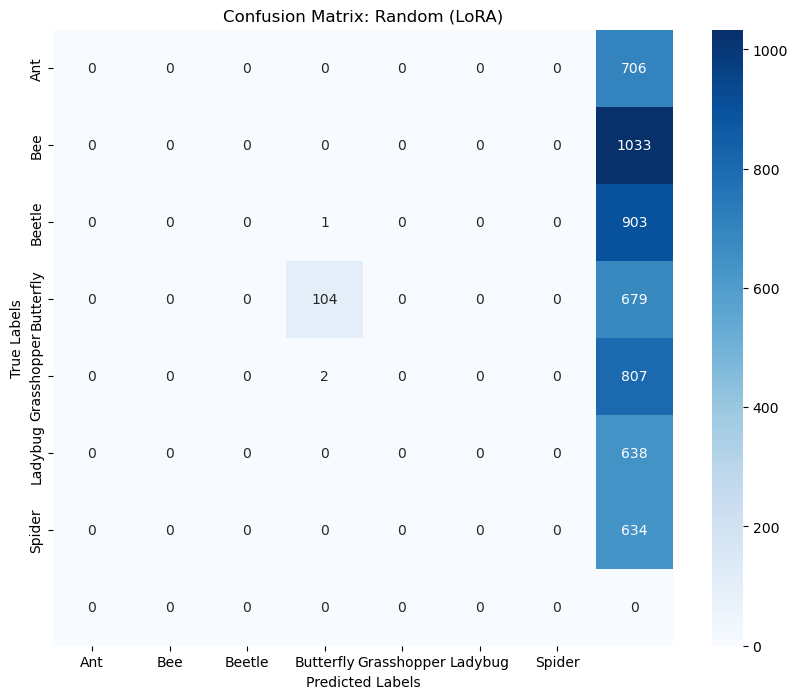

RESULT [Trial 4/10]: Acc: 0.0189 | F1: 0.0332 | AUC: 0.6335

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0002
  Test Weight F1: 0.0004
  Test AUC:       0.6070
  Train Time: 163.65s | Test Time: 201.0211s
  Confusion Matrix:


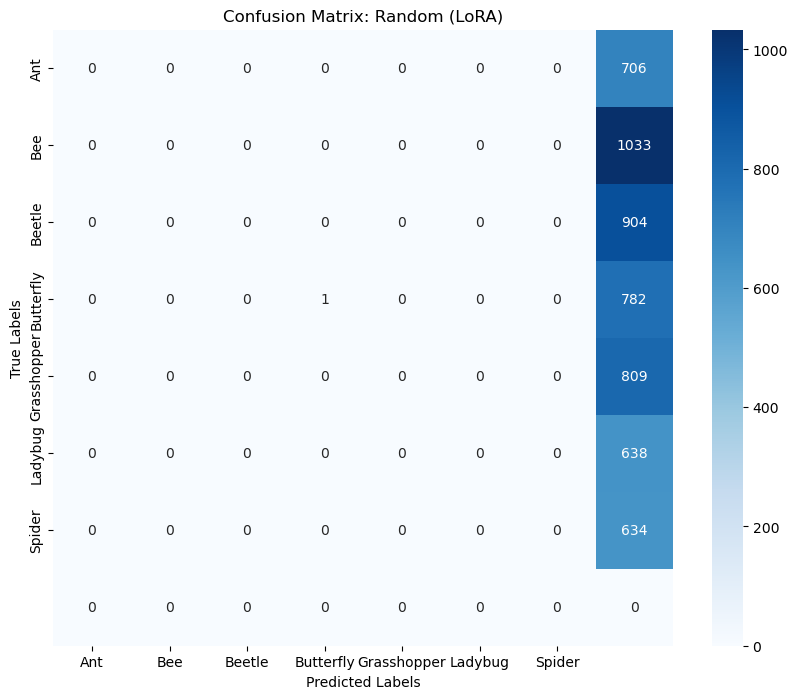

RESULT [Trial 5/10]: Acc: 0.0002 | F1: 0.0004 | AUC: 0.6070

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0263
  Test Weight F1: 0.0399
  Test AUC:       0.5628
  Train Time: 119.58s | Test Time: 195.0865s
  Confusion Matrix:


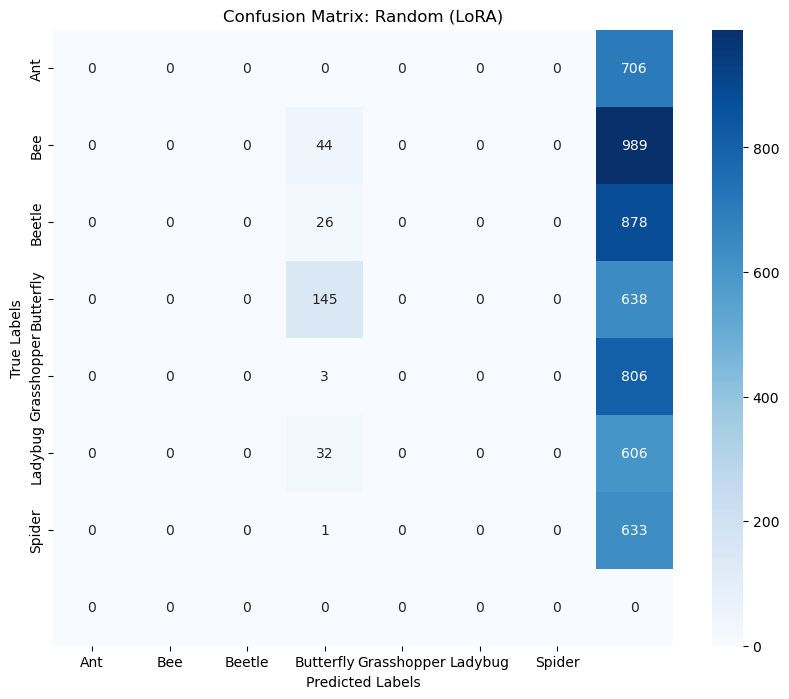

RESULT [Trial 6/10]: Acc: 0.0263 | F1: 0.0399 | AUC: 0.5628

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0009
  Test Weight F1: 0.0018
  Test AUC:       0.6404
  Train Time: 129.15s | Test Time: 195.6520s
  Confusion Matrix:


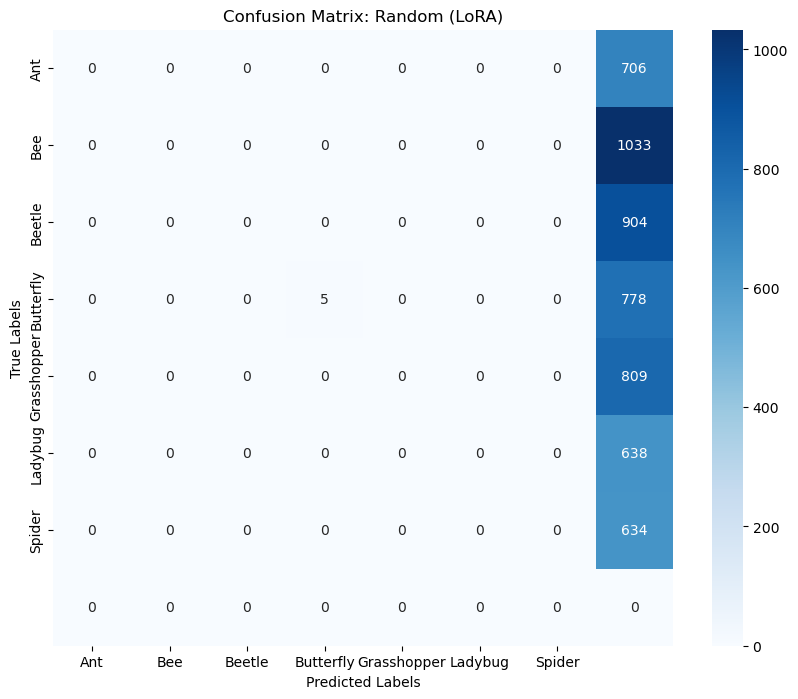

RESULT [Trial 7/10]: Acc: 0.0009 | F1: 0.0018 | AUC: 0.6404

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0000
  Test Weight F1: 0.0000
  Test AUC:       0.5650
  Train Time: 114.19s | Test Time: 166.6254s
  Confusion Matrix:


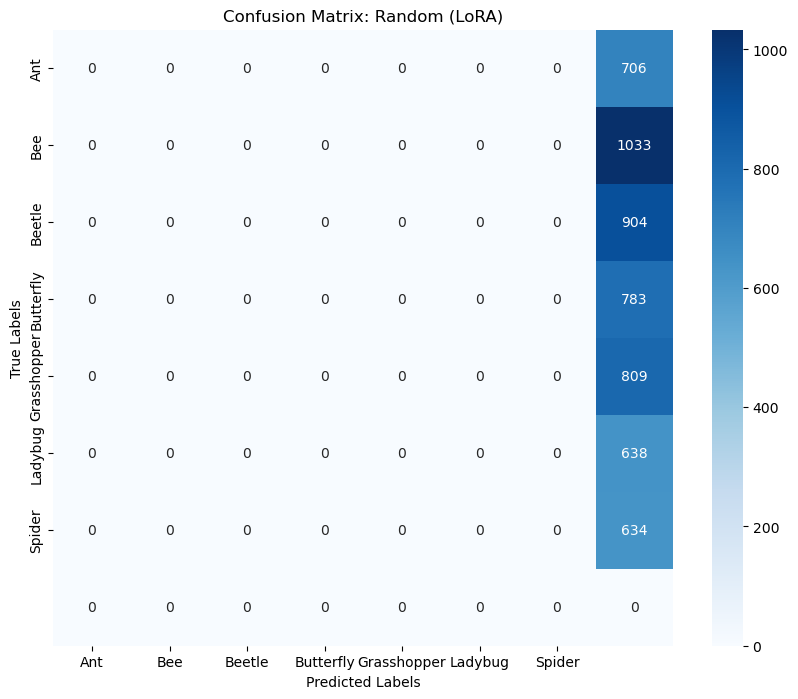

RESULT [Trial 8/10]: Acc: 0.0000 | F1: 0.0000 | AUC: 0.5650

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0597
  Test Weight F1: 0.0663
  Test AUC:       0.6607
  Train Time: 123.36s | Test Time: 170.0605s
  Confusion Matrix:


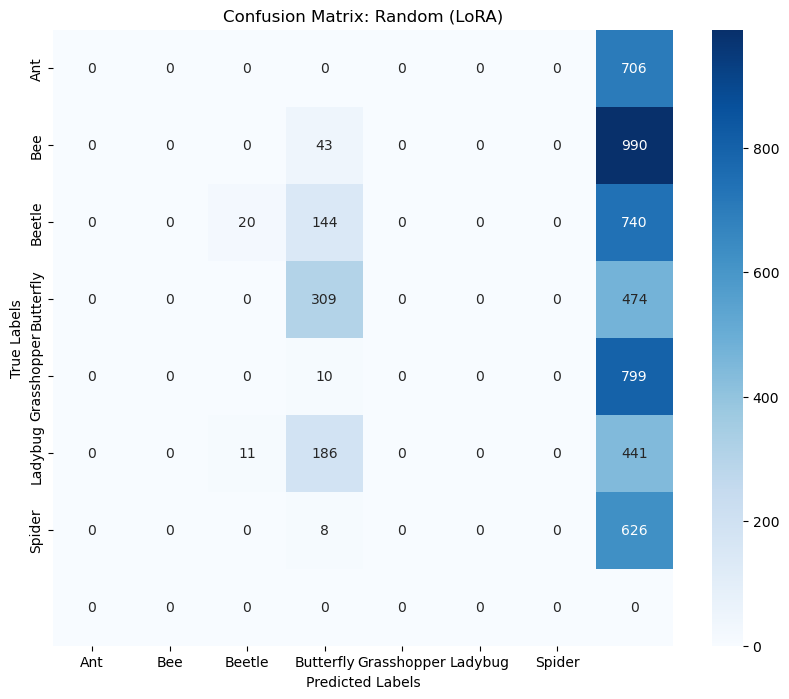

RESULT [Trial 9/10]: Acc: 0.0597 | F1: 0.0663 | AUC: 0.6607

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0176
  Test Weight F1: 0.0325
  Test AUC:       0.6158
  Train Time: 121.22s | Test Time: 172.0380s
  Confusion Matrix:


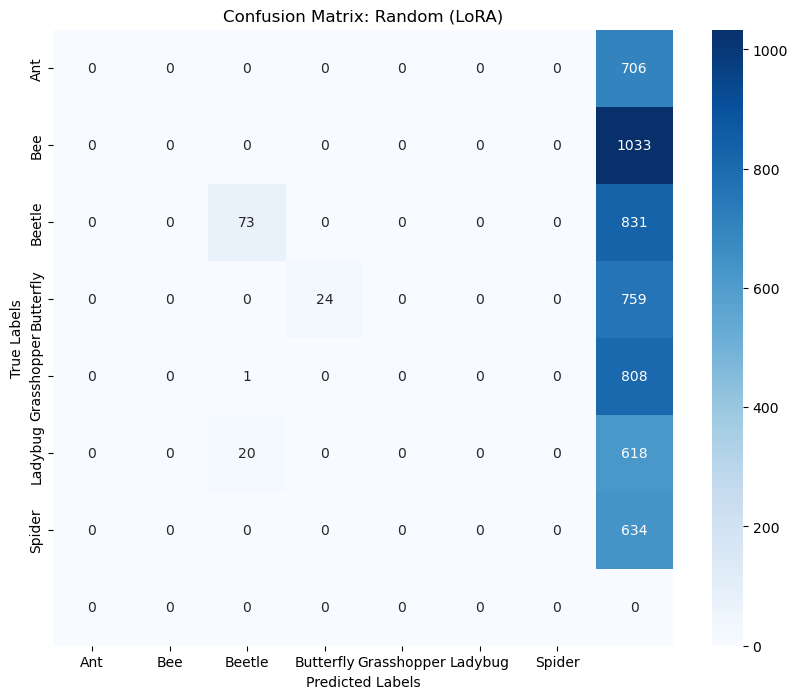

RESULT [Trial 10/10]: Acc: 0.0176 | F1: 0.0325 | AUC: 0.6158


In [51]:
target_size = len(cur_indices)
rand_metrics = []

for i in range(10):
    np.random.seed(42 + i)
    r_idx = np.random.choice(all_indices, size=target_size, replace=False).tolist()
    r_ds = InatPixelDataset(ds, r_idx, iNat36_label_df, transform=preprocess)
    
    # Run the trial
    res = run_experiment("Random (LoRA)", get_lora_model, r_ds, test_loader)
    
    # show metrics each round
    print(f"RESULT [Trial {i+1}/10]: Acc: {res['acc']:.4f} | F1: {res['f1']:.4f} | AUC: {res['auc']:.4f}")
    rand_metrics.append(res)

In [52]:
results_summary['Random (LoRA)'] = {
    'acc': np.mean([m['acc'] for m in rand_metrics]),
    'f1': np.mean([m['f1'] for m in rand_metrics]),
    'auc': np.mean([m['auc'] for m in rand_metrics]),
    'train_time': np.mean([m['train_time'] for m in rand_metrics]),
    'test_time': np.mean([m['test_time'] for m in rand_metrics]),
    'conf_matrix': rand_metrics[-1]['conf_matrix']
}

#### Curated Noise

#### Full Noise

#### Baseline (no training)

In [61]:
def get_baseline_model(num_classes):
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# def evaluate_baseline(model, test_loader, class_names):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model.to(device)
#     model.eval()
    
#     test_preds, test_probs, test_targets = [], [], []
#     start_time = time.time()
    
#     print("Starting baseline evaluation on test set...")
#     with torch.no_grad():
#         for imgs, labels in test_loader:
#             imgs = imgs.to(device)
#             outputs = model(imgs)
            
#             # collect probabilities for AUC and predictions for accuracy/F1
#             probs = torch.softmax(outputs, dim=1)
#             preds = torch.argmax(outputs, dim=1)
            
#             test_probs.extend(probs.cpu().numpy())
#             test_preds.extend(preds.cpu().numpy())
#             test_targets.extend(labels.numpy())
            
#     total_time = time.time() - start_time
    
#     # calculate metrics
#     unique_labels = np.arange(len(class_dirs))
#     acc = accuracy_score(test_targets, test_preds)
#     f1 = f1_score(test_targets, test_preds, average='weighted')

#     probs_array = np.array(test_probs)
#     print(f"Model output shape: {probs_array.shape}") # Should be (N, 8)
#     print(f"Number of class names: {len(class_names)}") # Likely 7
#     auc = roc_auc_score(test_targets, test_probs, multi_class='ovr', labels=unique_labels)
    
#     print(f"\n--- UN-FINETUNED BASELINE METRICS ---")
#     print(f"Accuracy:  {acc:.4f}")
#     print(f"F1-Score:  {f1:.4f}")
#     print(f"AUC:       {auc:.4f}")
#     print(f"Total Inference Time: {total_time:.2f} seconds")
    
#     # generate confusion matrix
#     cm = confusion_matrix(test_targets, test_preds)
#     plt.figure(figsize=(10, 8))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
#                 xticklabels=class_names, yticklabels=class_names)
#     plt.title('Confusion Matrix: Un-finetuned ResNet-50 Baseline')
#     plt.xlabel('Predicted')
#     plt.ylabel('Actual')
#     plt.show()

In [62]:
def evaluate_baseline(model, test_loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    test_preds, test_probs, test_targets = [], [], []
    start_time = time.time()
    
    print(f"Starting evaluation: Expected {len(class_names)} classes.")
    
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            
            # 1. Get Softmax probabilities
            probs = torch.softmax(outputs, dim=1)
            # 2. Get the predicted class index
            preds = torch.argmax(outputs, dim=1)
            
            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(labels.numpy())
            
    total_time = time.time() - start_time
    
    # --- PROBABILITY ALIGNMENT LOGIC ---
    test_probs_np = np.array(test_probs)
    num_model_outputs = test_probs_np.shape[1]
    num_expected_classes = len(class_names)
    
    # Slice if model has extra columns (e.g., 8 columns for 7 classes)
    if num_model_outputs > num_expected_classes:
        print(f"Alignment: Truncating {num_model_outputs} model outputs to match {num_expected_classes} classes.")
        test_probs_final = test_probs_np[:, :num_expected_classes]
        # Re-normalize so the 7 columns sum to 1.0 again
        test_probs_final = test_probs_final / (test_probs_final.sum(axis=1, keepdims=True) + 1e-10)
    else:
        test_probs_final = test_probs_np

    # Ensure predictions don't exceed our label range for the confusion matrix
    test_preds_final = [min(p, num_expected_classes - 1) for p in test_preds]
    unique_labels = np.arange(num_expected_classes)

    # --- METRIC CALCULATIONS ---
    acc = accuracy_score(test_targets, test_preds_final)
    f1 = f1_score(test_targets, test_preds_final, average='weighted')
    
    try:
        auc = roc_auc_score(
            test_targets, 
            test_probs_final, 
            multi_class='ovr', 
            average='weighted', 
            labels=unique_labels
        )
    except ValueError as e:
        print(f"Could not calculate AUC: {e}")
        auc = 0.0
    
    print(f"\n--- BASELINE METRICS ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    print(f"Time:      {total_time:.2f}s")
    
    # --- VISUALIZATION ---
    cm = confusion_matrix(test_targets, test_preds_final, labels=unique_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: Baseline Evaluation')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return {"acc": acc, "f1": f1, "auc": auc, "time": total_time}

Starting evaluation: Expected 7 classes.
Alignment: Truncating 8 model outputs to match 7 classes.

--- BASELINE METRICS ---
Accuracy:  0.1144
F1-Score:  0.0288
AUC:       0.5037
Time:      169.96s


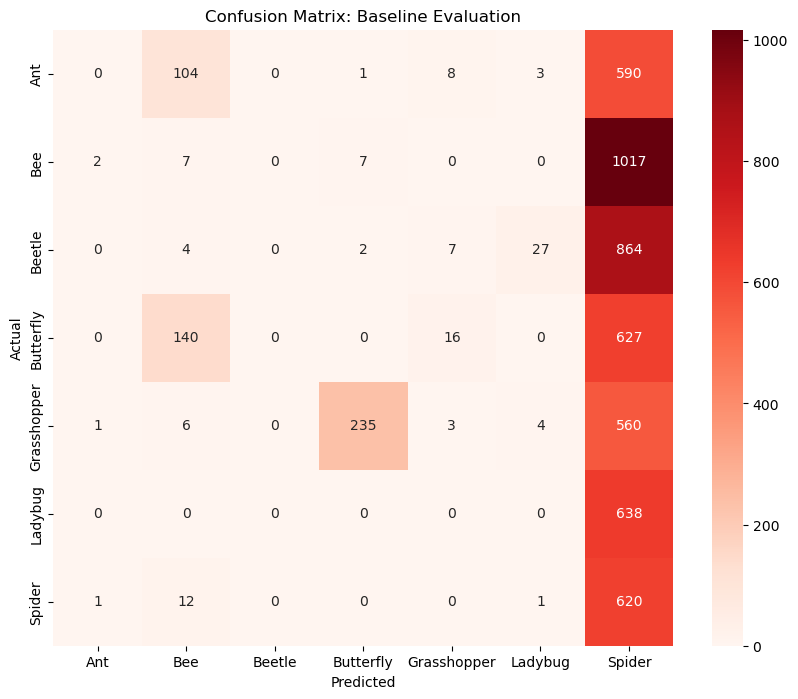

In [63]:
results_summary['Baseline'] = evaluate_baseline(get_baseline_model(num_classes), test_loader, class_dirs)

In [ ]:
results_summary['Baseline']

All results

In [64]:
print(f"\n{'='*70}")
print(f"{'Experiment':<25} | {'Acc':<7} | {'F1':<7} | {'AUC':<7}")
print(f"{'-'*70}")
for name, m in results_summary.items():
    print(f"{name:<25} | {m['acc']:.4f} | {m['f1']:.4f} | {m['auc']:.4f}")
print(f"{'='*70}")


Experiment                | Acc     | F1      | AUC    
----------------------------------------------------------------------
Curated_partial           | 0.7427 | 0.7282 | 0.9514
Curated_LoRA              | 0.4685 | 0.4009 | 0.9130
Full_partial              | 0.6219 | 0.6998 | 0.9599
Full_LoRA                 | 0.4325 | 0.4617 | 0.9087
Random (10-avg)           | 0.4706 | 0.5298 | 0.9410
Random (LoRA)             | 0.0292 | 0.0375 | 0.6197
Baseline                  | 0.1144 | 0.0288 | 0.5037


### Curated Metrics across Data Size


--- Training on top 10.0% important samples ---

--- Training on top 20.0% important samples ---

--- Training on top 40.0% important samples ---

--- Training on top 60.0% important samples ---

--- Training on top 80.0% important samples ---

--- Training on top 100.0% important samples ---


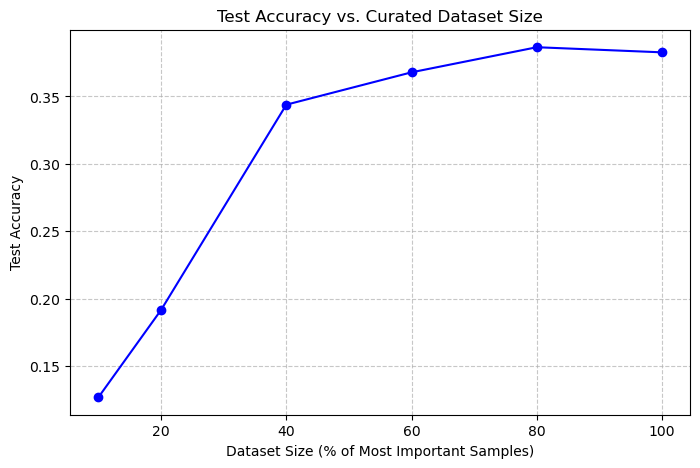

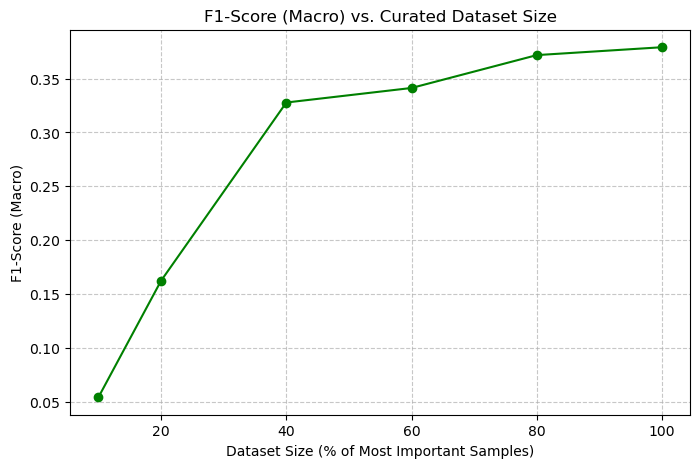

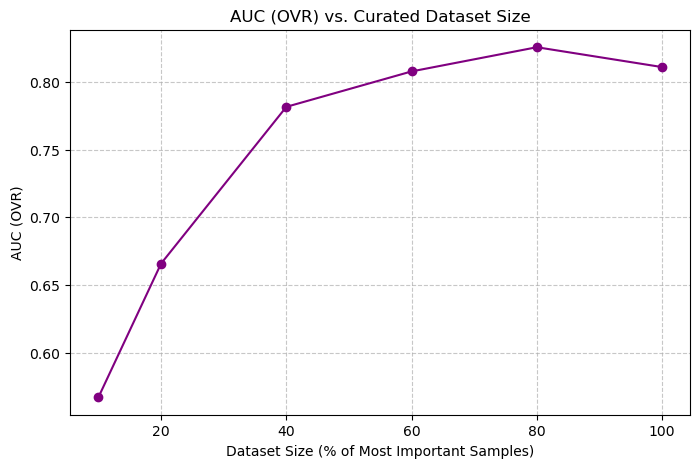

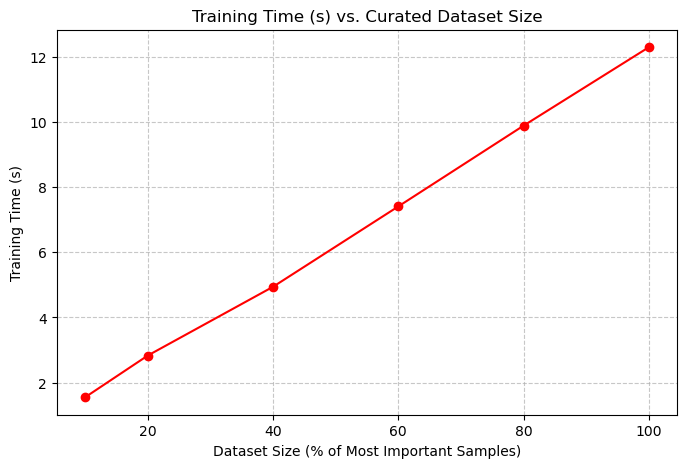

In [67]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 5
SIZES = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

all_curated_indices = cur_indices

def get_metrics(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    return acc, f1, auc

# main training loop
results = {'size': [], 'acc': [], 'f1': [], 'auc': [], 'time': []}

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

for s in SIZES:
    print(f"\n--- Training on top {s*100}% important samples ---")
    
    # slice from the END of the list
    num_samples = int(len(all_curated_indices) * s)
    selected_indices = all_curated_indices[-num_samples:]
    train_subset = Subset(full_train, selected_indices)
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    
    model = torchvision.models.resnet18(num_classes=10).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    start_time = time.time()
    model.train()
    for epoch in range(EPOCHS):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
    
    end_time = time.time()
    
    # collect metrics
    acc, f1, auc = get_metrics(model, test_loader)
    
    results['size'].append(s * 100)
    results['acc'].append(acc)
    results['f1'].append(f1)
    results['auc'].append(auc)
    results['time'].append(end_time - start_time)

# graphing
metrics_to_plot = [
    ('Test Accuracy', 'acc', 'blue'),
    ('F1-Score (Macro)', 'f1', 'green'),
    ('AUC (OVR)', 'auc', 'purple'),
    ('Training Time (s)', 'time', 'red')
]

for title, key, color in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.plot(results['size'], results[key], marker='o', linestyle='-', color=color)
    plt.title(f'{title} vs. Curated Dataset Size')
    plt.xlabel('Dataset Size (% of Most Important Samples)')
    plt.ylabel(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()